In [1]:
import os
import hydra
from hydra import initialize, compose

from deletme3D.data.components.seg_3dataset import Segmentation3Dataset
from deletme3D.data.augmend_wrapper import AugmendWrapper

os.environ["PROJECT_ROOT"] = "../"

initialize(version_base="1.3", config_path="../configs", job_name="notebook_visualization")
cfg = compose(config_name="train.yaml", overrides=["experiment=segmentation", "renorm="])

In [2]:
dataset: Segmentation3Dataset = hydra.utils.instantiate(cfg.data.train_data)

100%|██████████| 9/9 [00:10<00:00,  1.22s/it]


Initial movies


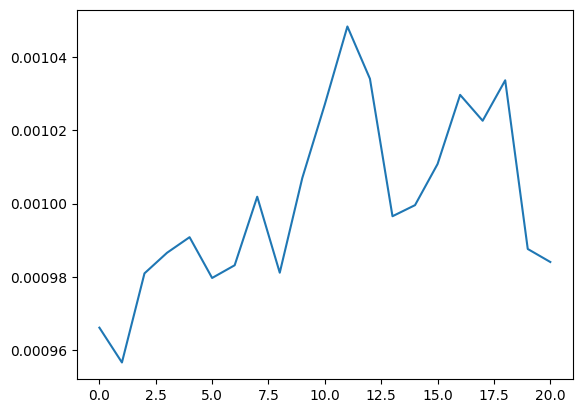

percentile-0.5-99.5


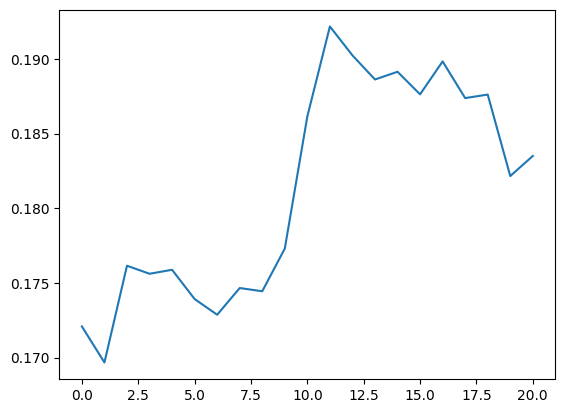

In [28]:
import numpy as np
from matplotlib import pyplot as plt

def plot_movies_means(movies, method=np.mean):
    all_means = None
    for movie in movies:
        means = method(movie, axis=(1, 2, 3))
        if all_means is None:
            all_means = means
        else:
            end_index = min(all_means.shape[0], means.shape[0])
            all_means[:end_index] += means[:end_index]
            all_means[:end_index] /= 2
            if all_means.shape[0] < means.shape[0]:
                all_means = np.append(all_means, means[all_means.shape[0]:])
    
    x = range(all_means.shape[0])
    fig = plt.figure()
    plt.plot(x, all_means)
    plt.show()

def normalize_min_max(movie):
    res = movie.copy()
    return (res - res.min()) / (res.ptp() + 1e-6)

def normalize_movie(movie):
    # Take first frame mean
        
    res = movie.copy()
    # For each frame in the movie
    for i in range(movie.shape[0]):
        # Normalize all Z axis
        for z_idx in range(movie[i].shape[-1]):
            sl = res[i, ..., z_idx]
            low_percentile = np.percentile(sl, 1)
            sl = np.where(sl > low_percentile)
            real_slice = res[i, ..., z_idx][sl]
            if real_slice.shape[0] == 0:
                continue
            res[i, ..., z_idx][sl] = (real_slice - real_slice.min()) / (real_slice.ptp() + 1e-6)
    return res

def twice_norm(movie):
    return normalize_min_max(normalize_movie(movie))


def percentile(min_per=1, max_per=99):
    def normalize_by_frame(x):
        x = x.copy()
        for i in range(x.shape[0]):
            x[i] = normalize_percentile(x[i])
        return x

    def normalize_percentile(x):
        percentile_low = np.percentile(x, min_per)
        percentile_high = np.percentile(x, max_per)
        x = (x - percentile_low) / (percentile_high - percentile_low)
        # x = np.clip(x, x.min(), np.percentile(x, max_per))
        return x
    return normalize_by_frame

print("Initial movies")
plot_movies_means(dataset.movies_im, np.mean)
normalizations = {
    # "min_max": normalize_min_max,
    "percentile-0.5-99.5": percentile(0.5, 99.5),
    # "percentile-1-99": percentile(1, 99),
    # "percentile-5-95": percentile(5, 95),
    # "percentile-10-90": percentile(10, 90)
}
normalized_movies = {norm_name: [] for norm_name in normalizations.keys()}
for i in range(len(dataset.movies_im)):
    for norm_name, normalization in normalizations.items():
        normalized_movies[norm_name].append(normalization(dataset.movies_im[i]))

for norm_name, normed in normalized_movies.items():
    print(norm_name)
    plot_movies_means(normed, np.mean)    

In [31]:
import napari
viewer = napari.Viewer()

def display_item(viewer, x, xns):
    viewer.add_image(x, name='im', colormap='magma', contrast_limits=[0, 0.01])
    for norm_name, value in xns.items():
        viewer.add_image(value, name=f'im_{norm_name}', colormap='magma', contrast_limits=[0, 2.0])

idx = 4

movie_ref = dataset.movies_im[idx]

for i in range(len(movie_ref)):
    x = movie_ref[i]
    xns = {}
    for norm, value in normalized_movies.items():
        print(len(value))
        xn = value[idx][i]
        xns[norm] = xn
    display_item(viewer, x, xns)

viewer.show()

9
9
9
9
9
9
9
9
9
9
